Connected to omics (Python 3.7.10)

In [1]:
import sklearn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.stats.multitest as ssm
import scipy as sp
import pickle
import sys
import os
import re
import matplotlib
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans
from yellowbrick.cluster import KElbowVisualizer
import plotly.express as px
from sklearn.decomposition import PCA
from scipy import stats
from statsmodels.stats.multitest import multipletests


sns.set(font = 'Arial')
sns.set_style("whitegrid")
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42

In [2]:
def read_go_file(file_path):
    go_terms = {}
    with open(file_path, 'r') as file:
        for line in file:
            # Split the line into GO term and genes, assuming they are separated by tabs
            parts = line.strip().split('\t', 1)
            if len(parts) == 2:
                go_term, genes = parts
                genes_list = genes.split()  # Splitting gene symbols which are separated by spaces
                go_terms[go_term] = genes_list
    return go_terms

go_terms = read_go_file('/home/jiye/jiye/copycomparison/OC_transcriptome/GO_Biological_Process_2021.txt')
TU = pd.read_csv('/home/jiye/jiye/copycomparison/gDUTresearch/FINALDATA/80_discovery_TU.txt', sep='\t')
ratio = pd.read_csv('/home/jiye/jiye/copycomparison/gDUTresearch/majorminor/major2minorratio.txt', sep='\t') 
sampleinfo = pd.read_csv('/home/jiye/jiye/copycomparison/gDUTresearch/FINALDATA/sorted_discovery_fileinfo.txt', sep='\t')
responder = sampleinfo.loc[(sampleinfo['response']==1),'sample_full'].to_list()
nonresponder = sampleinfo.loc[(sampleinfo['response']==0),'sample_full'].to_list()

##* AR
ARdut = pd.read_csv('/home/jiye/jiye/copycomparison/gDUTresearch/202311_analysis/DUT/responder_stable_DUT_Wilcoxon.txt', sep='\t')
major = pd.read_csv('/home/jiye/jiye/copycomparison/gDUTresearch/FINALDATA/2024majorminorinfo.txt', sep='\t')
majorlist = major[major['type']=='major']


###* AR ####
gDUTlist = list(set(ARdut.loc[(ARdut['p_value']<0.05) & (ARdut['log2FC']>1.5), 'Gene Symbol']))
DUTlist = list(ARdut.loc[(ARdut['p_value']<0.05) & (ARdut['log2FC']>1.5), 'gene_ENST'])

##############################################################
#enr = pd.read_csv('/home/jiye/jiye/copycomparison/gDUTresearch/202403_analysis/DUT/responder_stable_DUT_GOenrichment.txt', sep='\t')
enr = pd.read_csv('/home/jiye/jiye/copycomparison/gDUTresearch/202403_analysis/DUT/AR_stable_distDUT_GOenrichment.txt', sep='\t')
##############################################################
enr = enr[(enr["Term"].str.contains("repair", case=False)) | (enr["Term"].str.contains("DNA Damage", case=False))]
enr = enr[enr["Adjusted P-value"]<=0.1]

In [3]:
import sklearn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.stats.multitest as ssm
import scipy as sp
import pickle
import sys
import os
import re
import matplotlib
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans
from yellowbrick.cluster import KElbowVisualizer
import plotly.express as px
from sklearn.decomposition import PCA
from scipy import stats
from statsmodels.stats.multitest import multipletests


sns.set(font = 'Arial')
sns.set_style("whitegrid")
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42

In [4]:
def read_go_file(file_path):
    go_terms = {}
    with open(file_path, 'r') as file:
        for line in file:
            # Split the line into GO term and genes, assuming they are separated by tabs
            parts = line.strip().split('\t', 1)
            if len(parts) == 2:
                go_term, genes = parts
                genes_list = genes.split()  # Splitting gene symbols which are separated by spaces
                go_terms[go_term] = genes_list
    return go_terms

go_terms = read_go_file('/home/jiye/jiye/copycomparison/OC_transcriptome/GO_Biological_Process_2021.txt')
TU = pd.read_csv('/home/jiye/jiye/copycomparison/gDUTresearch/FINALDATA/80_discovery_TU.txt', sep='\t')
ratio = pd.read_csv('/home/jiye/jiye/copycomparison/gDUTresearch/majorminor/major2minorratio.txt', sep='\t') 
sampleinfo = pd.read_csv('/home/jiye/jiye/copycomparison/gDUTresearch/FINALDATA/sorted_discovery_fileinfo.txt', sep='\t')
responder = sampleinfo.loc[(sampleinfo['response']==1),'sample_full'].to_list()
nonresponder = sampleinfo.loc[(sampleinfo['response']==0),'sample_full'].to_list()
major = pd.read_csv('/home/jiye/jiye/copycomparison/gDUTresearch/FINALDATA/2024majorminorinfo.txt', sep='\t')

majorlist = major[major['type']=='major']

In [5]:
major

,gene_ENST,transcriptid,genename,type
0,ENST00000595014.1-A1BG,ENST00000595014.1,A1BG,minor
1,ENST00000596924.1-A1BG,ENST00000596924.1,A1BG,minor
2,ENST00000263100.3-A1BG,ENST00000263100.3,A1BG,major
3,ENST00000598345.1-A1BG,ENST00000598345.1,A1BG,minor
4,ENST00000600966.1-A1BG,ENST00000600966.1,A1BG,minor
...,...,...,...,...
338162,MSTRG.2805.1-ZZZ3,MSTRG.2805.1,ZZZ3,minor
338163,MSTRG.2807.1-ZZZ3,MSTRG.2807.1,ZZZ3,minor
338164,MSTRG.2810.1-ZZZ3,MSTRG.2810.1,ZZZ3,minor
338165,ENST00000458763.2-ZZZ3,ENST00000458763.2,ZZZ3,minor


In [6]:
majorlist

,gene_ENST,transcriptid,genename,type
2,ENST00000263100.3-A1BG,ENST00000263100.3,A1BG,major
5,ENST00000373993.1-A1CF,ENST00000373993.1,A1CF,major
11,ENST00000282641.2-A1CF,ENST00000282641.2,A1CF,major
22,ENST00000299698.7-A2ML1,ENST00000299698.7,A2ML1,major
37,ENST00000318602.7-A2M,ENST00000318602.7,A2M,major
...,...,...,...,...
338067,ENST00000294353.6-ZYG11B,ENST00000294353.6,ZYG11B,major
338081,MSTRG.4330.92-ZYG11B,MSTRG.4330.92,ZYG11B,major
338097,ENST00000322764.5-ZYX,ENST00000322764.5,ZYX,major
338100,ENST00000381638.2-ZZEF1,ENST00000381638.2,ZZEF1,major


In [7]:
##* AR
ARdut = pd.read_csv('/home/jiye/jiye/copycomparison/gDUTresearch/202311_analysis/DUT/responder_stable_DUT_Wilcoxon.txt', sep='\t')
major = pd.read_csv('/home/jiye/jiye/copycomparison/gDUTresearch/FINALDATA/2024majorminorinfo.txt', sep='\t')
majorlist = major[major['type']=='major']


###* AR ####
gDUTlist = list(set(ARdut.loc[(ARdut['p_value']<0.05) & (ARdut['log2FC']>1.5), 'Gene Symbol']))
DUTlist = list(ARdut.loc[(ARdut['p_value']<0.05) & (ARdut['log2FC']>1.5), 'gene_ENST'])

##############################################################
enr = pd.read_csv('/home/jiye/jiye/copycomparison/gDUTresearch/202403_analysis/DUT/responder_stable_DUT_GOenrichment.txt', sep='\t')
#enr = pd.read_csv('/home/jiye/jiye/copycomparison/gDUTresearch/202403_analysis/DUT/AR_stable_distDUT_GOenrichment.txt', sep='\t')
##############################################################
enr = enr[(enr["Term"].str.contains("repair", case=False)) | (enr["Term"].str.contains("DNA Damage", case=False))]
enr = enr[enr["Adjusted P-value"]<=0.01]

In [8]:
enr

,Gene_set,Term,Overlap,P-value,Adjusted P-value,Old P-value,Old Adjusted P-value,Odds Ratio,Combined Score,Genes
4,GO_Biological_Process_2021,cellular response to DNA damage stimulus (GO:0...,226/350,4.687946e-13,5.604908e-10,0,0,2.203694,62.559803,ATF2;SMARCAL1;CCNK;SMC5;SMC6;BACH1;ALKBH8;ALKB...
57,GO_Biological_Process_2021,DNA repair (GO:0006281),177/298,1.020596e-06,1.051918e-04,0,0,1.759493,24.272429,MDC1;SMARCAL1;DCLRE1A;DCLRE1C;MPG;NUCKS1;BACH1...
116,GO_Biological_Process_2021,"DNA damage response, signal transduction by p5...",51/74,4.205988e-05,2.130796e-03,0,0,2.654024,26.743053,BTG2;CDKN1A;FOXM1;ING4;CHEK2;CASP2;EP300;TNKS1...
149,GO_Biological_Process_2021,mitotic G1 DNA damage checkpoint signaling (GO...,45/65,9.929573e-05,3.957952e-03,0,0,2.692017,24.813423,BTG2;CDKN1A;PRKDC;RPS27L;AURKA;MUC1;CCND1;PCBP...
160,GO_Biological_Process_2021,nucleotide-excision repair (GO:0006289),67/105,1.273561e-04,4.728788e-03,0,0,2.111155,18.933940,CETN2;OGG1;BRCA2;POLB;EP300;POLK;POLE;HMGN1;RF...
175,GO_Biological_Process_2021,intrinsic apoptotic signaling pathway in respo...,18/21,1.770832e-04,5.980808e-03,0,0,7.168626,61.928977,DYRK2;RPS27L;AEN;HIPK1;USP28;SIRT1;PML;HIPK2;B...
177,GO_Biological_Process_2021,double-strand break repair (GO:0006302),98/164,1.790211e-04,6.012293e-03,0,0,1.779416,15.352810,DCLRE1A;MDC1;SMARCAL1;DCLRE1C;RIF1;NUCKS1;SMC5...


In [9]:
##* IR
dut = pd.read_csv('/home/jiye/jiye/copycomparison/gDUTresearch/202311_analysis/DUT/nonresponder_stable_DUT_Wilcoxon.txt', sep='\t')

###################################################################
dutdf= dut.loc[(dut['p_value']<0.05) & (dut['log2FC']>1.5)]
majorDUTgene = set(dutdf['Gene Symbol'])
#majordutdf = dutdf[dutdf['gene_ENST'].isin(majorlist)]
#majorDUTgene = set(majordutdf['Gene Symbol'])
###################################################################

with open('/home/jiye/jiye/copycomparison/gDUTresearch/202403_analysis/DUTgene/IR_DUTgenelist.txt') as file:
    distDUTlist = [line.rstrip() for line in file]

#IR_DUTgene = set(distDUTlist).union(majorDUTgene)
IR_DUTgene = majorDUTgene

print(len(distDUTlist), len(majorDUTgene))

#################### MODEL INPUT ##########################
#bothlist = list(AR_DUTgene.union(IR_DUTgene))
#GO_DUTgene = list(set(bothlist).intersection(set(go_terms['double-strand break repair (GO:0006302)'])))

# with open('/home/jiye/jiye/copycomparison/gDUTresearch/202403_analysis/DUTgene/dsb_ARIR_both_DUTlist.txt', "w") as file:
#     for item in GO_DUTgene:
#         file.write("%s\n" % item)

339 2309


In [10]:
##*AR
dut = pd.read_csv('/home/jiye/jiye/copycomparison/gDUTresearch/202311_analysis/DUT/responder_stable_DUT_Wilcoxon.txt', sep='\t')
###################################################################
dutdf= dut.loc[(dut['p_value']<0.05) & (dut['log2FC']>1.5)]
majorDUTgene = set(dutdf['Gene Symbol'])
#majordutdf = dutdf[dutdf['gene_ENST'].isin(majorlist)]
#majorDUTgene = set(majordutdf['Gene Symbol'])
###################################################################


with open('/home/jiye/jiye/copycomparison/gDUTresearch/202403_analysis/DUTgene/AR_DUTgenelist.txt') as file:
    distDUTlist = [line.rstrip() for line in file]

#AR_DUTgene = set(distDUTlist).union(majorDUTgene)
AR_DUTgene = majorDUTgene
print(len(distDUTlist), len(majorDUTgene))

2224 8639


In [11]:
AR_DUTgene

{'RAPGEF3',
 'PEX6',
 'CSGALNACT1',
 'GABRR2',
 'ZNF579',
 'GNPTG',
 'SEZ6L',
 'MAP1LC3B',
 'GSTT2',
 'PPP2R4',
 'TANGO2',
 'CPT1C',
 'MIER1',
 'SLC30A8',
 'PPP3CC',
 'STAT1',
 'ZC3H7A',
 'SNAP47',
 'CD276',
 'OPN3',
 'CHD1L',
 'RBM20',
 'TMEM119',
 'CDH6',
 'SEMA6C',
 'C12orf4',
 'DRD3',
 'FHAD1',
 'ZC3H7B',
 'ZDHHC9',
 'PPP2R2D',
 'FAU',
 'PPIP5K1',
 'SNF8',
 'SERF1B',
 'TNFRSF10B',
 'PROSER1',
 'SMARCB1',
 'TAF6',
 'DDAH1',
 'ANKRD36',
 'METTL14',
 'SLC25A13',
 'TMEM234',
 'TOR1AIP1',
 'NECAB1',
 'BCAT1',
 'TRNT1',
 'SPTB',
 'KDM3A',
 'FAM78B',
 'NPM1',
 'SERAC1',
 'ARNTL',
 'NKAIN4',
 'AVIL',
 'MEGF11',
 'ZBTB17',
 'DPT',
 'SERPINB1',
 'MSR1',
 'TAMM41',
 'LRRC41',
 'ALKBH3',
 'BRE',
 'KLHDC4',
 'SPG20',
 'L2HGDH',
 'RUFY4',
 'KLHL42',
 'BAZ2B',
 'CNTROB',
 'CCDC81',
 'CRISPLD2',
 'KCNN2',
 'MST4',
 'IGBP1',
 'CMC2',
 'SLC25A30',
 'ANKRD52',
 'PHLDB1',
 'DDX4',
 'RNF34',
 'SLC25A23',
 'EZH1',
 'PRR16',
 'GORASP2',
 'ZNF239',
 'PLEKHG1',
 'IPO4',
 'GOLGA8M',
 'TBC1D2B',
 'HES7',
 'M

In [12]:
len(AR_DUTgene)

8639

In [13]:
len(IR_DUTgene)

2309

In [14]:
go_terms

{"'de novo' posttranslational protein folding (GO:0051084)": ['SDF2L1',
  'HSPA9',
  'CCT2',
  'ST13',
  'HSPA6',
  'ENTPD5',
  'HSPA5',
  'PTGES3',
  'HSPA1L',
  'HSPA8',
  'DNAJB13',
  'HSPA2',
  'DNAJB14',
  'HSPE1',
  'DNAJC18',
  'GAK',
  'DNAJC7',
  'DNAJB12',
  'HSPA1A',
  'HSPA1B',
  'ERO1A',
  'SELENOF',
  'HSPA14',
  'HSPA13',
  'DNAJB1',
  'CHCHD4',
  'BAG1',
  'DNAJB5',
  'DNAJB4',
  'SDF2',
  'UGGT1'],
 '2-oxoglutarate metabolic process (GO:0006103)': ['IDH1',
  'PHYH',
  'AADAT',
  'GOT2',
  'MRPS36',
  'GOT1',
  'IDH2',
  'ADHFE1',
  'GPT2',
  'TAT',
  'DLST',
  'L2HGDH',
  'D2HGDH',
  'OGDH'],
 "3'-phosphoadenosine 5'-phosphosulfate biosynthetic process (GO:0050428)": ['SLC26A1',
  'SLC35B3',
  'SLC26A2',
  'SLC35B2',
  'PAPSS1',
  'PAPSS2'],
 "3'-phosphoadenosine 5'-phosphosulfate metabolic process (GO:0050427)": ['ABHD14B',
  'TPST2',
  'SULT2B1',
  'SULT1B1',
  'TPST1',
  'SULT6B1',
  'SLC26A1',
  'SLC35B3',
  'SLC26A2',
  'SLC35B2',
  'PAPSS1',
  'PAPSS2',
  'SULT2A

Using zero_method  wilcox
pre v.s. post: Wilcoxon test (paired samples) with Bonferroni correction, P_val=1.445e-02 stat=2.135e+04
0
1
Using zero_method  wilcox
pre v.s. post: Wilcoxon test (paired samples) with Bonferroni correction, P_val=1.056e-01 stat=2.285e+04
0
1
Using zero_method  wilcox
pre v.s. post: Wilcoxon test (paired samples) with Bonferroni correction, P_val=3.602e-02 stat=1.536e+04
0
1
Using zero_method  wilcox
pre v.s. post: Wilcoxon test (paired samples) with Bonferroni correction, P_val=1.915e-01 stat=1.649e+04
0
1
Using zero_method  wilcox
pre v.s. post: Wilcoxon test (paired samples) with Bonferroni correction, P_val=9.543e-01 stat=1.268e+03
0
1
Using zero_method  wilcox
pre v.s. post: Wilcoxon test (paired samples) with Bonferroni correction, P_val=2.212e-01 stat=1.096e+03
0
1
Using zero_method  wilcox
pre v.s. post: Wilcoxon test (paired samples) with Bonferroni correction, P_val=6.380e-01 stat=8.800e+02
0
1
Using zero_method  wilcox
pre v.s. post: Wilcoxon test 

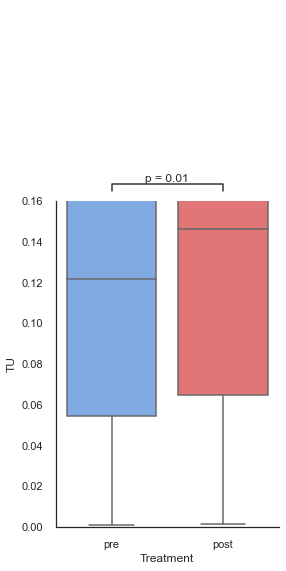

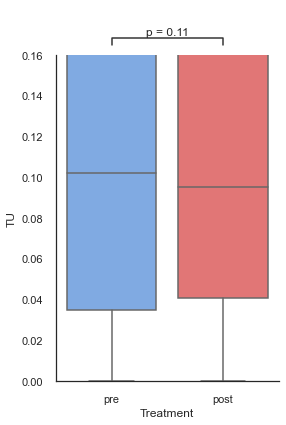

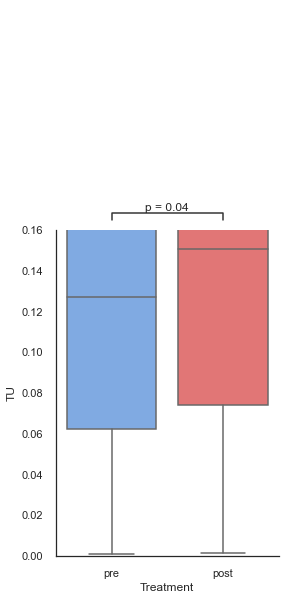

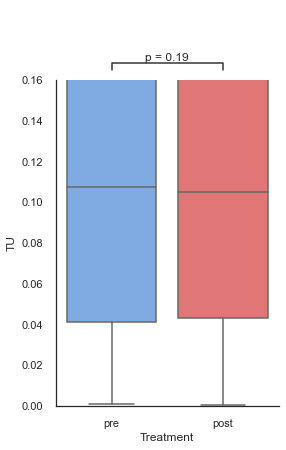

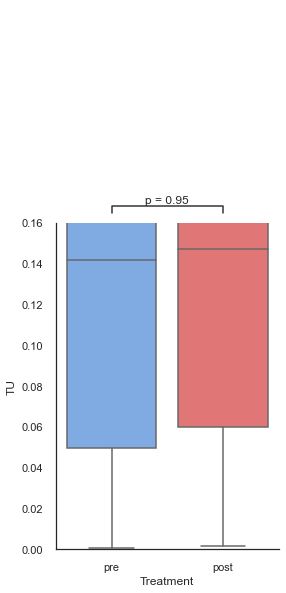

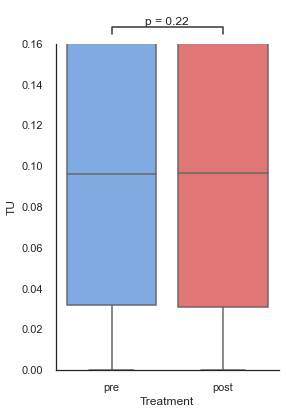

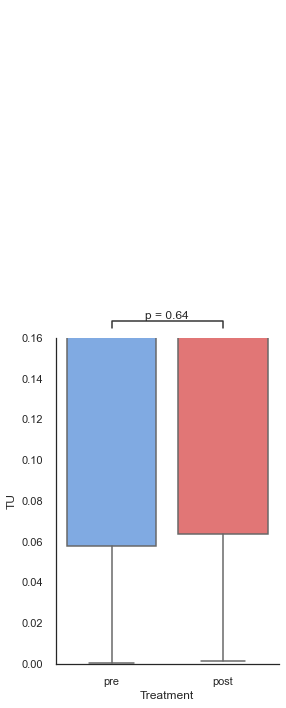

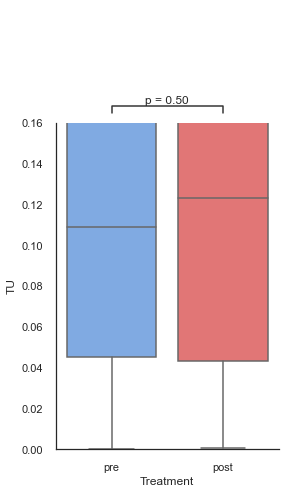

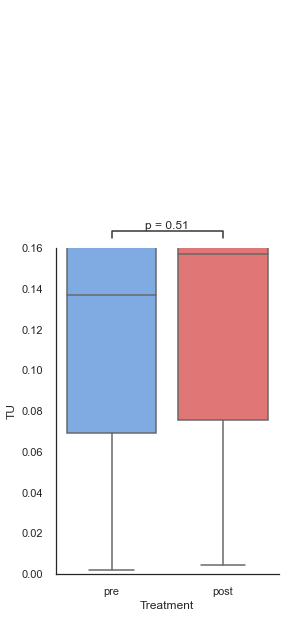

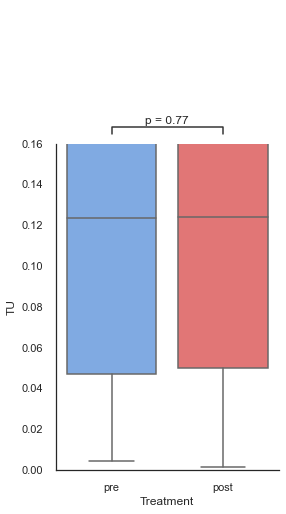

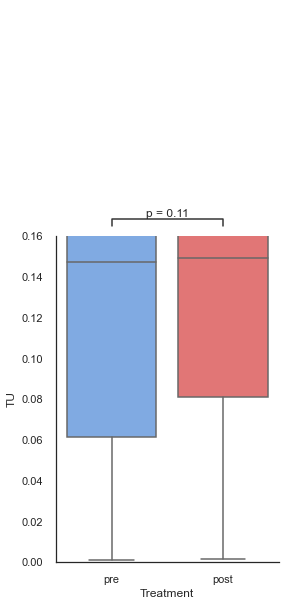

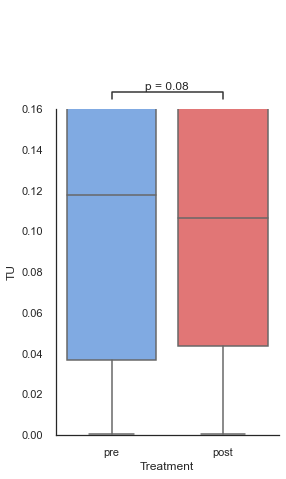

In [15]:
term_list = ['cellular response to DNA damage stimulus (GO:0006974)', 'DNA repair (GO:0006281)', 'DNA damage response, signal transduction by p53 class mediator (GO:0030330)', 'mitotic G1 DNA damage checkpoint signaling (GO:0031571)', 'nucleotide-excision repair (GO:0006289)','double-strand break repair (GO:0006302)']


DUTlist = [AR_DUTgene, IR_DUTgene]
responder = sampleinfo.loc[(sampleinfo['response']==1),'sample_full'].to_list()
nonresponder = sampleinfo.loc[(sampleinfo['response']==0),'sample_full'].to_list()
samplelist = [responder,nonresponder]
namelist = ['AR','IR']

###^^^ Major Sum #########################
for term in term_list:
    GO_genelist = go_terms[term]
    for i in range(0,2):
        enrmajorlist = majorlist[majorlist['genename'].isin(GO_genelist)]['gene_ENST']
        new_df = TU.set_index(['gene_ENST'])
        new_df = new_df[new_df.index.isin(enrmajorlist)]

        ###################responder / nonresponder##########################
        new_df = new_df[samplelist[i]]
        #####################################################################

        ## summation of majot TUs in same gene ##
        new_df['gene'] = new_df.index.str.split("-",1).str[1]
        new_df = new_df.reset_index()
        new_df = new_df.groupby('gene').sum()
        new_df = new_df.reset_index().set_index('gene')

        df_bfD = new_df[[col for col in new_df.columns if '-bfD' in col]]
        df_atD = new_df[[col for col in new_df.columns if '-atD' in col]]

        mean_bfD = list(df_bfD.mean(axis=1))
        mean_atD = list(df_atD.mean(axis=1))
        meandict = {'pre': mean_bfD, 'post': mean_atD}
        meandf = pd.DataFrame(meandict)
        meandf.index = new_df.index

        plt.figure(figsize=(4,6))
        sns.set_style("white")

        col1 = ["#70A8F2","#F36464"]

        tmplist = meandf.index.to_list()
        tmplist = tmplist*2

        ##
        figureinput = meandf.melt(var_name='Treatment', value_name='TU')
        figureinput['gene'] = tmplist
        ##


        ax = sns.boxplot(x="Treatment", y="TU", data=figureinput,  palette=col1, showfliers=False)
        plt.ylim(0,0.16)

        from statannot import add_stat_annotation

        add_stat_annotation(ax, data=figureinput, x='Treatment', y='TU',
                    box_pairs=[("pre", "post")],
                    test='Wilcoxon', text_format='simple', loc='outside', #comparisons_correction=None,
                    )
        #plt.figtext(0.5, 1.005, namelist2[i] + ' - ' + typelist[j]+' transcript exp', ha='center', va='center', fontsize=13)
        #plt.title(namelist2[i] + ' - ' + typelist[j]+' transcript exp', fontsize=13, y=3)
        medians = figureinput.groupby(['Treatment'])['TU'].median()
        medians = medians.iloc[::-1]
        medians = medians.round(decimals=5)
        vertical_offset = figureinput['TU'].median() * 0.8

        for xtick in ax.get_xticks():
            print(xtick)
            ax.text(xtick, medians[xtick] + vertical_offset, medians[xtick], 
                    horizontalalignment='center',size='medium',color='w',weight='semibold')
            
        sns.despine()

Using zero_method  wilcox
pre v.s. post: Wilcoxon test (paired samples) with Bonferroni correction, P_val=1.445e-02 stat=2.135e+04
0
1
Using zero_method  wilcox
pre v.s. post: Wilcoxon test (paired samples) with Bonferroni correction, P_val=1.056e-01 stat=2.285e+04
0
1
Using zero_method  wilcox
pre v.s. post: Wilcoxon test (paired samples) with Bonferroni correction, P_val=3.602e-02 stat=1.536e+04
0
1
Using zero_method  wilcox
pre v.s. post: Wilcoxon test (paired samples) with Bonferroni correction, P_val=1.915e-01 stat=1.649e+04
0
1
Using zero_method  wilcox
pre v.s. post: Wilcoxon test (paired samples) with Bonferroni correction, P_val=9.543e-01 stat=1.268e+03
0
1
Using zero_method  wilcox
pre v.s. post: Wilcoxon test (paired samples) with Bonferroni correction, P_val=2.212e-01 stat=1.096e+03
0
1
Using zero_method  wilcox
pre v.s. post: Wilcoxon test (paired samples) with Bonferroni correction, P_val=6.380e-01 stat=8.800e+02
0
1
Using zero_method  wilcox
pre v.s. post: Wilcoxon test 

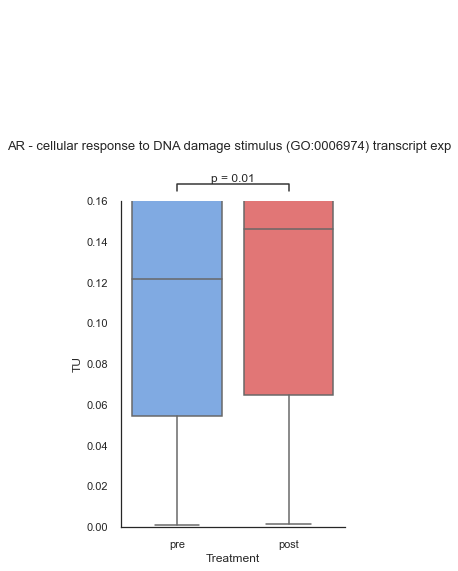

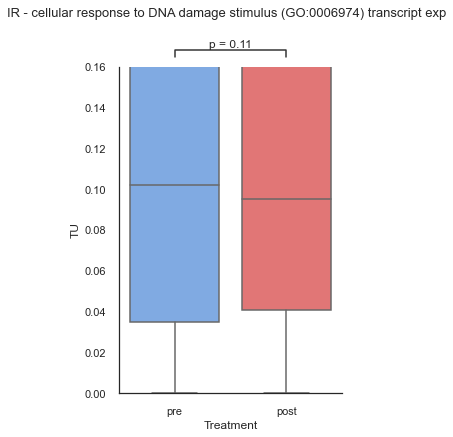

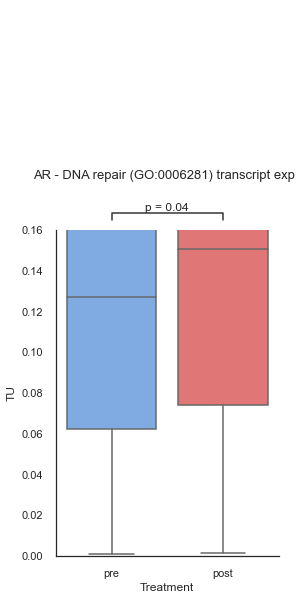

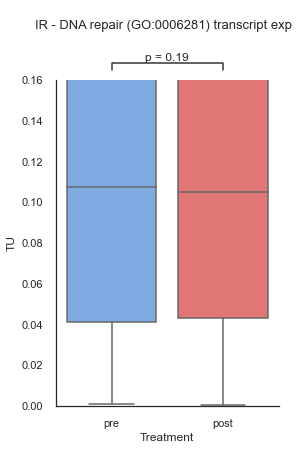

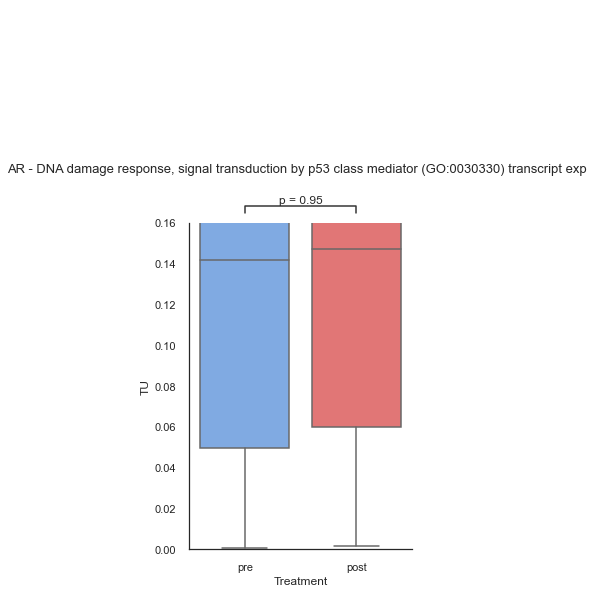

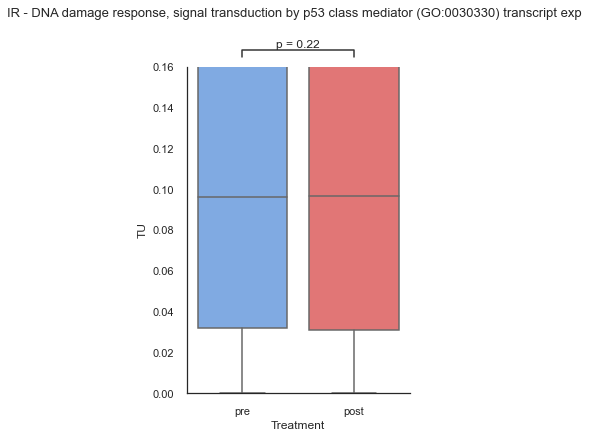

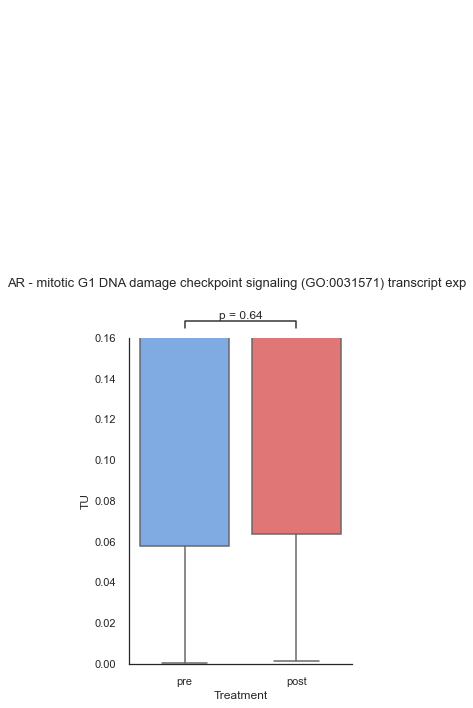

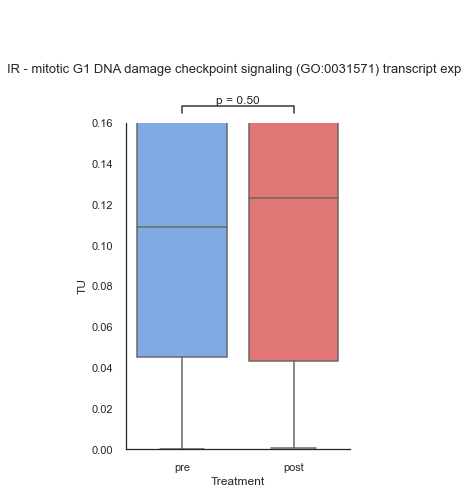

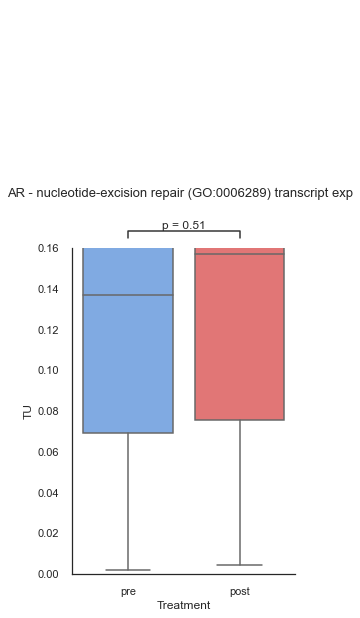

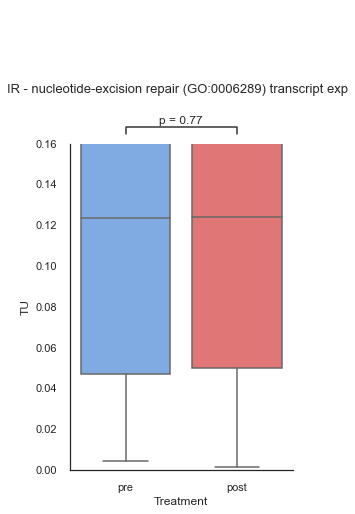

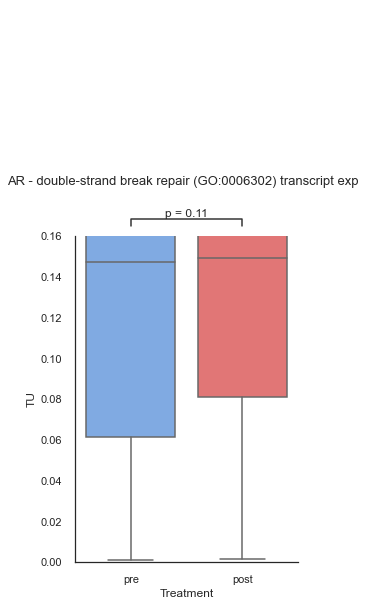

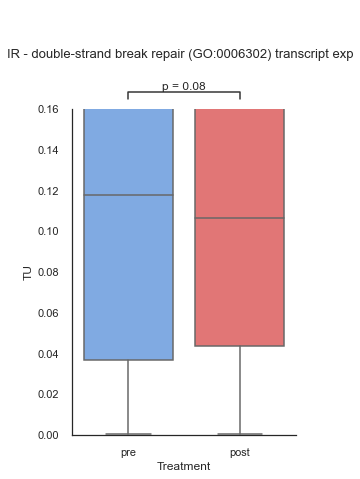

In [16]:
term_list = ['cellular response to DNA damage stimulus (GO:0006974)', 'DNA repair (GO:0006281)', 'DNA damage response, signal transduction by p53 class mediator (GO:0030330)', 'mitotic G1 DNA damage checkpoint signaling (GO:0031571)', 'nucleotide-excision repair (GO:0006289)','double-strand break repair (GO:0006302)']


DUTlist = [AR_DUTgene, IR_DUTgene]
responder = sampleinfo.loc[(sampleinfo['response']==1),'sample_full'].to_list()
nonresponder = sampleinfo.loc[(sampleinfo['response']==0),'sample_full'].to_list()
samplelist = [responder,nonresponder]
namelist = ['AR','IR']

###^^^ Major Sum #########################
for term in term_list:
    GO_genelist = go_terms[term]
    for i in range(0,2):
        enrmajorlist = majorlist[majorlist['genename'].isin(GO_genelist)]['gene_ENST']
        new_df = TU.set_index(['gene_ENST'])
        new_df = new_df[new_df.index.isin(enrmajorlist)]

        ###################responder / nonresponder##########################
        new_df = new_df[samplelist[i]]
        #####################################################################

        ## summation of majot TUs in same gene ##
        new_df['gene'] = new_df.index.str.split("-",1).str[1]
        new_df = new_df.reset_index()
        new_df = new_df.groupby('gene').sum()
        new_df = new_df.reset_index().set_index('gene')

        df_bfD = new_df[[col for col in new_df.columns if '-bfD' in col]]
        df_atD = new_df[[col for col in new_df.columns if '-atD' in col]]

        mean_bfD = list(df_bfD.mean(axis=1))
        mean_atD = list(df_atD.mean(axis=1))
        meandict = {'pre': mean_bfD, 'post': mean_atD}
        meandf = pd.DataFrame(meandict)
        meandf.index = new_df.index

        plt.figure(figsize=(4,6))
        sns.set_style("white")

        col1 = ["#70A8F2","#F36464"]

        tmplist = meandf.index.to_list()
        tmplist = tmplist*2

        ##
        figureinput = meandf.melt(var_name='Treatment', value_name='TU')
        figureinput['gene'] = tmplist
        ##


        ax = sns.boxplot(x="Treatment", y="TU", data=figureinput,  palette=col1, showfliers=False)
        plt.ylim(0,0.16)

        from statannot import add_stat_annotation

        add_stat_annotation(ax, data=figureinput, x='Treatment', y='TU',
                    box_pairs=[("pre", "post")],
                    test='Wilcoxon', text_format='simple', loc='outside', #comparisons_correction=None,
                    )
        plt.figtext(0.5, 1.005, namelist[i] + ' - ' + term+' transcript exp', ha='center', va='center', fontsize=13)
        #plt.title(namelist2[i] + ' - ' + typelist[j]+' transcript exp', fontsize=13, y=3)
        medians = figureinput.groupby(['Treatment'])['TU'].median()
        medians = medians.iloc[::-1]
        medians = medians.round(decimals=5)
        vertical_offset = figureinput['TU'].median() * 0.8

        for xtick in ax.get_xticks():
            print(xtick)
            ax.text(xtick, medians[xtick] + vertical_offset, medians[xtick], 
                    horizontalalignment='center',size='medium',color='w',weight='semibold')
            
        sns.despine()

Using zero_method  wilcox
pre v.s. post: Wilcoxon test (paired samples) with Bonferroni correction, P_val=1.445e-02 stat=2.135e+04
0
1
Using zero_method  wilcox
pre v.s. post: Wilcoxon test (paired samples) with Bonferroni correction, P_val=1.056e-01 stat=2.285e+04
0
1
Using zero_method  wilcox
pre v.s. post: Wilcoxon test (paired samples) with Bonferroni correction, P_val=3.602e-02 stat=1.536e+04
0
1
Using zero_method  wilcox
pre v.s. post: Wilcoxon test (paired samples) with Bonferroni correction, P_val=1.915e-01 stat=1.649e+04
0
1
Using zero_method  wilcox
pre v.s. post: Wilcoxon test (paired samples) with Bonferroni correction, P_val=9.543e-01 stat=1.268e+03
0
1
Using zero_method  wilcox
pre v.s. post: Wilcoxon test (paired samples) with Bonferroni correction, P_val=2.212e-01 stat=1.096e+03
0
1
Using zero_method  wilcox
pre v.s. post: Wilcoxon test (paired samples) with Bonferroni correction, P_val=6.380e-01 stat=8.800e+02
0
1
Using zero_method  wilcox
pre v.s. post: Wilcoxon test 

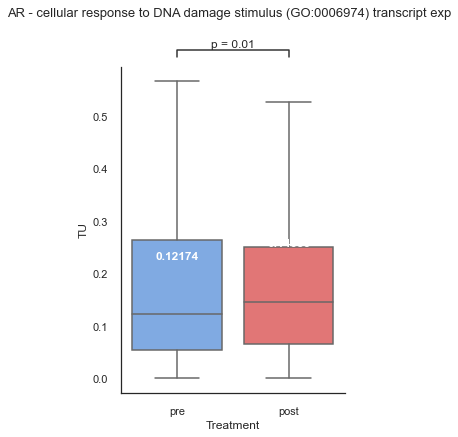

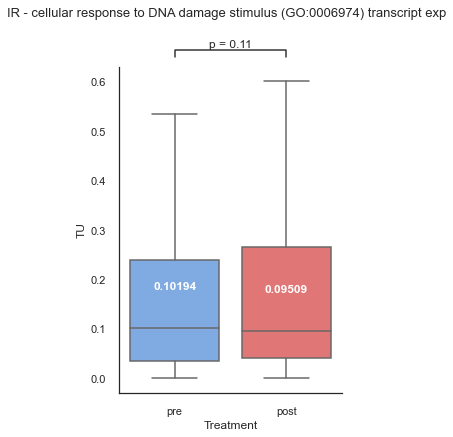

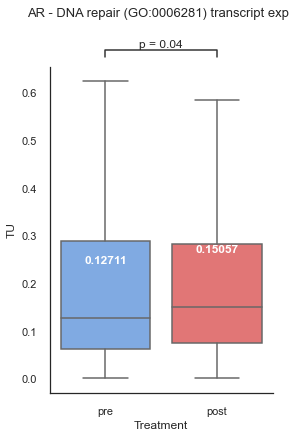

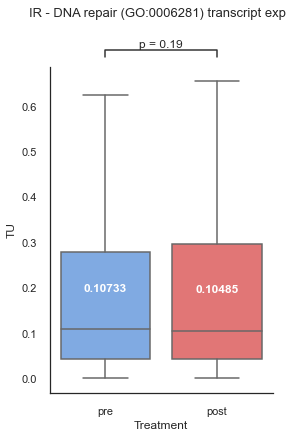

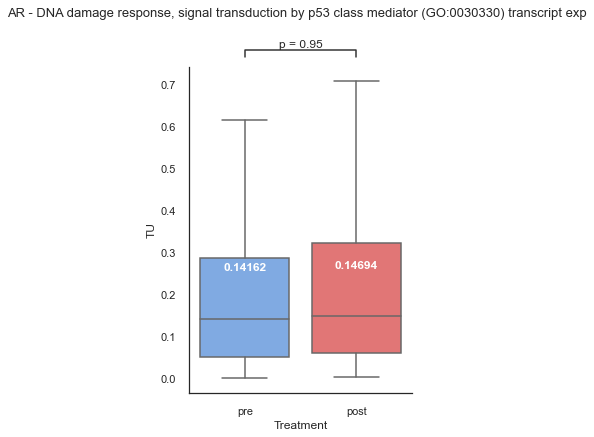

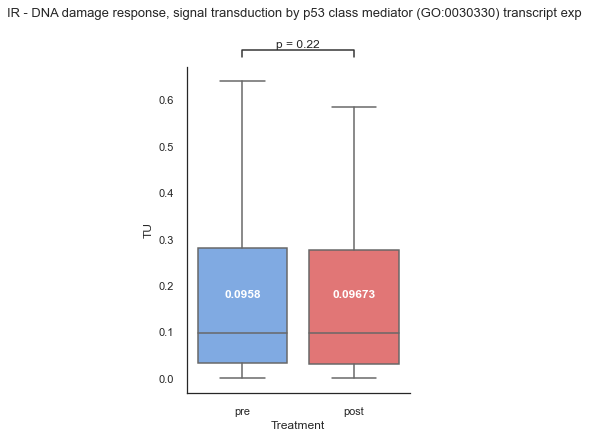

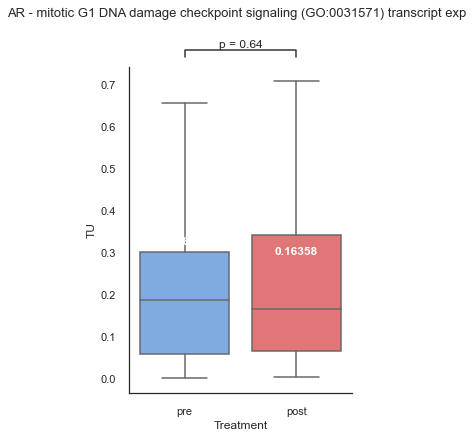

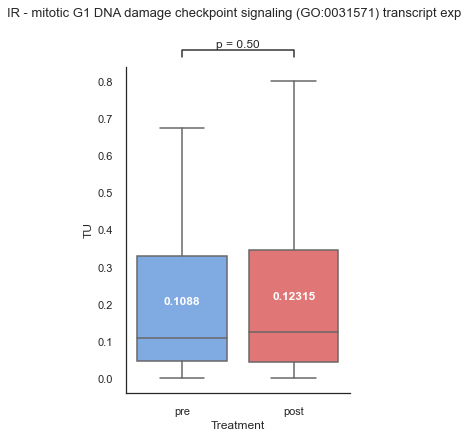

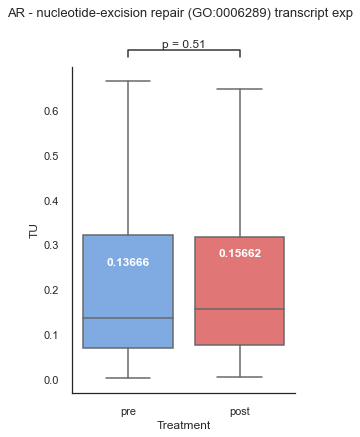

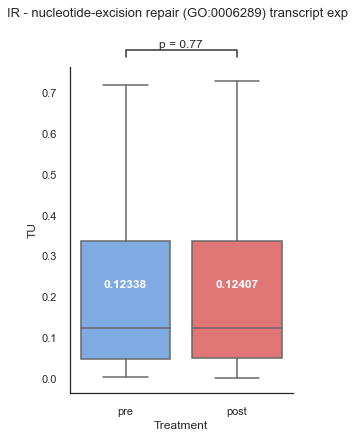

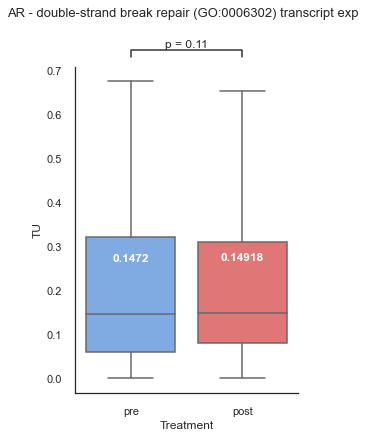

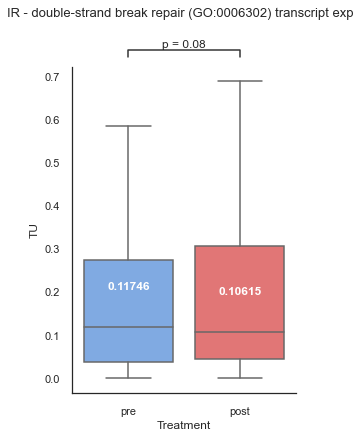

In [17]:
term_list = ['cellular response to DNA damage stimulus (GO:0006974)', 'DNA repair (GO:0006281)', 'DNA damage response, signal transduction by p53 class mediator (GO:0030330)', 'mitotic G1 DNA damage checkpoint signaling (GO:0031571)', 'nucleotide-excision repair (GO:0006289)','double-strand break repair (GO:0006302)']


DUTlist = [AR_DUTgene, IR_DUTgene]
responder = sampleinfo.loc[(sampleinfo['response']==1),'sample_full'].to_list()
nonresponder = sampleinfo.loc[(sampleinfo['response']==0),'sample_full'].to_list()
samplelist = [responder,nonresponder]
namelist = ['AR','IR']

###^^^ Major Sum #########################
for term in term_list:
    GO_genelist = go_terms[term]
    for i in range(0,2):
        enrmajorlist = majorlist[majorlist['genename'].isin(GO_genelist)]['gene_ENST']
        new_df = TU.set_index(['gene_ENST'])
        new_df = new_df[new_df.index.isin(enrmajorlist)]

        ###################responder / nonresponder##########################
        new_df = new_df[samplelist[i]]
        #####################################################################

        ## summation of majot TUs in same gene ##
        new_df['gene'] = new_df.index.str.split("-",1).str[1]
        new_df = new_df.reset_index()
        new_df = new_df.groupby('gene').sum()
        new_df = new_df.reset_index().set_index('gene')

        df_bfD = new_df[[col for col in new_df.columns if '-bfD' in col]]
        df_atD = new_df[[col for col in new_df.columns if '-atD' in col]]

        mean_bfD = list(df_bfD.mean(axis=1))
        mean_atD = list(df_atD.mean(axis=1))
        meandict = {'pre': mean_bfD, 'post': mean_atD}
        meandf = pd.DataFrame(meandict)
        meandf.index = new_df.index

        plt.figure(figsize=(4,6))
        sns.set_style("white")

        col1 = ["#70A8F2","#F36464"]

        tmplist = meandf.index.to_list()
        tmplist = tmplist*2

        ##
        figureinput = meandf.melt(var_name='Treatment', value_name='TU')
        figureinput['gene'] = tmplist
        ##


        ax = sns.boxplot(x="Treatment", y="TU", data=figureinput,  palette=col1, showfliers=False)
        #plt.ylim(0,0.16)

        from statannot import add_stat_annotation

        add_stat_annotation(ax, data=figureinput, x='Treatment', y='TU',
                    box_pairs=[("pre", "post")],
                    test='Wilcoxon', text_format='simple', loc='outside', #comparisons_correction=None,
                    )
        plt.figtext(0.5, 1.005, namelist[i] + ' - ' + term+' transcript exp', ha='center', va='center', fontsize=13)
        #plt.title(namelist2[i] + ' - ' + typelist[j]+' transcript exp', fontsize=13, y=3)
        medians = figureinput.groupby(['Treatment'])['TU'].median()
        medians = medians.iloc[::-1]
        medians = medians.round(decimals=5)
        vertical_offset = figureinput['TU'].median() * 0.8

        for xtick in ax.get_xticks():
            print(xtick)
            ax.text(xtick, medians[xtick] + vertical_offset, medians[xtick], 
                    horizontalalignment='center',size='medium',color='w',weight='semibold')
            
        sns.despine()

Using zero_method  wilcox
pre v.s. post: Wilcoxon test (paired samples) with Bonferroni correction, P_val=1.445e-02 stat=2.135e+04
0
1
Using zero_method  wilcox
pre v.s. post: Wilcoxon test (paired samples) with Bonferroni correction, P_val=1.056e-01 stat=2.285e+04
0
1
Using zero_method  wilcox
pre v.s. post: Wilcoxon test (paired samples) with Bonferroni correction, P_val=3.602e-02 stat=1.536e+04
0
1
Using zero_method  wilcox
pre v.s. post: Wilcoxon test (paired samples) with Bonferroni correction, P_val=1.915e-01 stat=1.649e+04
0
1
Using zero_method  wilcox
pre v.s. post: Wilcoxon test (paired samples) with Bonferroni correction, P_val=9.543e-01 stat=1.268e+03
0
1
Using zero_method  wilcox
pre v.s. post: Wilcoxon test (paired samples) with Bonferroni correction, P_val=2.212e-01 stat=1.096e+03
0
1
Using zero_method  wilcox
pre v.s. post: Wilcoxon test (paired samples) with Bonferroni correction, P_val=6.380e-01 stat=8.800e+02
0
1
Using zero_method  wilcox
pre v.s. post: Wilcoxon test 

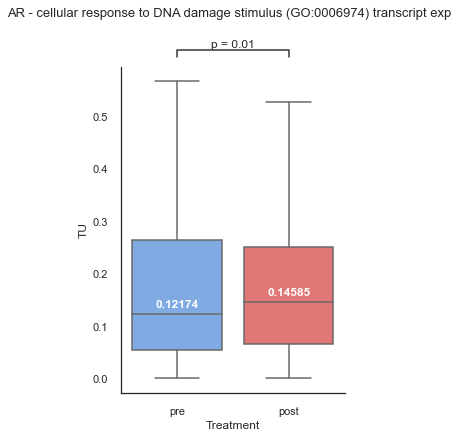

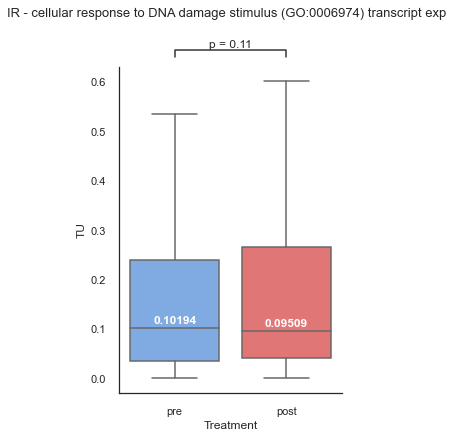

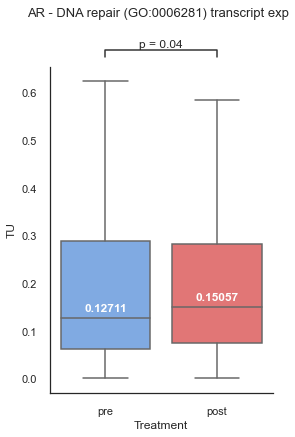

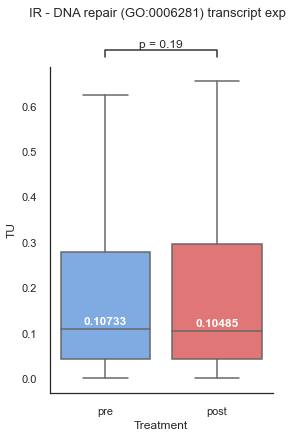

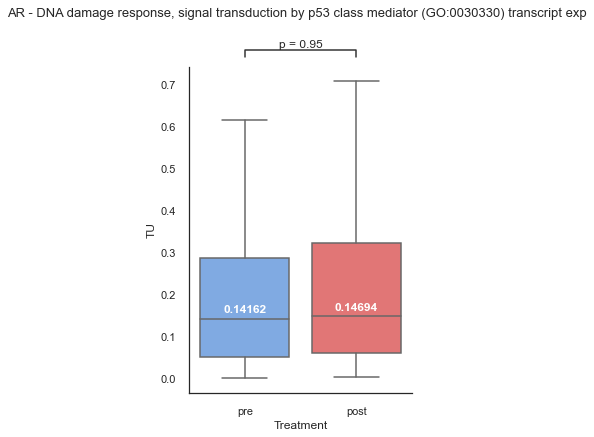

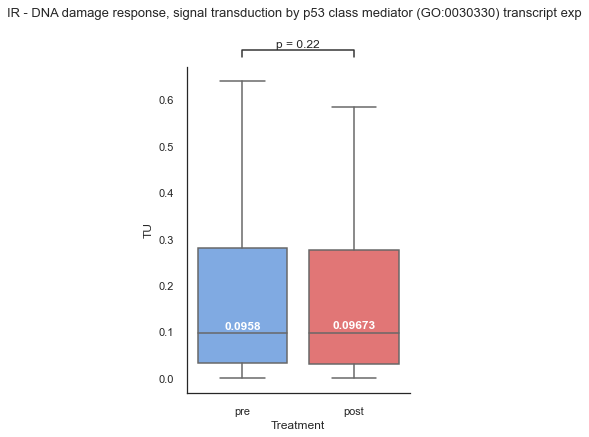

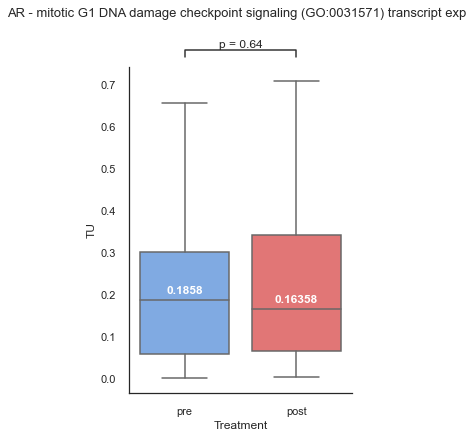

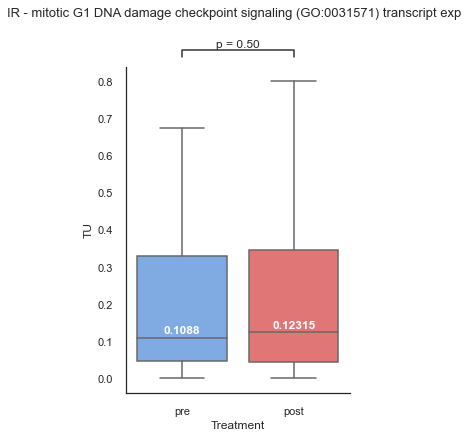

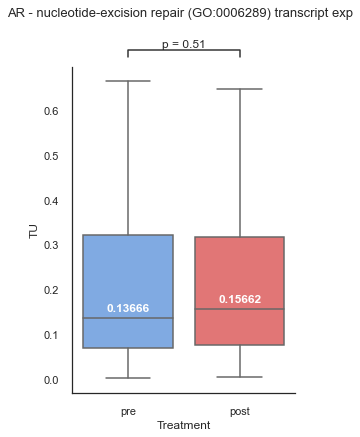

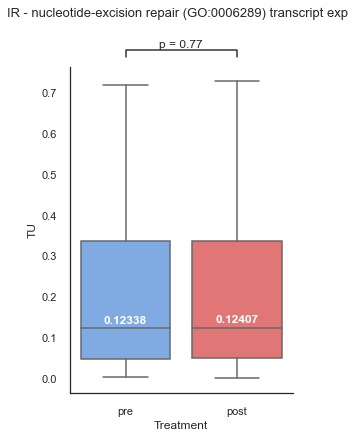

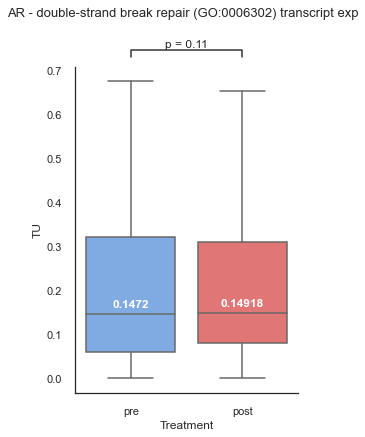

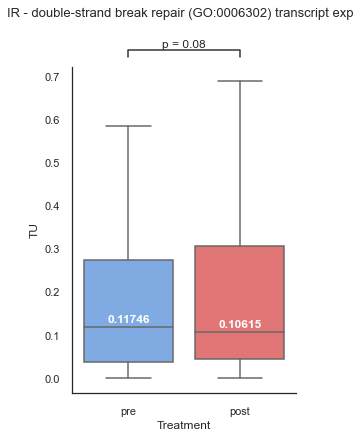

In [18]:
term_list = ['cellular response to DNA damage stimulus (GO:0006974)', 'DNA repair (GO:0006281)', 'DNA damage response, signal transduction by p53 class mediator (GO:0030330)', 'mitotic G1 DNA damage checkpoint signaling (GO:0031571)', 'nucleotide-excision repair (GO:0006289)','double-strand break repair (GO:0006302)']


DUTlist = [AR_DUTgene, IR_DUTgene]
responder = sampleinfo.loc[(sampleinfo['response']==1),'sample_full'].to_list()
nonresponder = sampleinfo.loc[(sampleinfo['response']==0),'sample_full'].to_list()
samplelist = [responder,nonresponder]
namelist = ['AR','IR']

###^^^ Major Sum #########################
for term in term_list:
    GO_genelist = go_terms[term]
    for i in range(0,2):
        enrmajorlist = majorlist[majorlist['genename'].isin(GO_genelist)]['gene_ENST']
        new_df = TU.set_index(['gene_ENST'])
        new_df = new_df[new_df.index.isin(enrmajorlist)]

        ###################responder / nonresponder##########################
        new_df = new_df[samplelist[i]]
        #####################################################################

        ## summation of majot TUs in same gene ##
        new_df['gene'] = new_df.index.str.split("-",1).str[1]
        new_df = new_df.reset_index()
        new_df = new_df.groupby('gene').sum()
        new_df = new_df.reset_index().set_index('gene')

        df_bfD = new_df[[col for col in new_df.columns if '-bfD' in col]]
        df_atD = new_df[[col for col in new_df.columns if '-atD' in col]]

        mean_bfD = list(df_bfD.mean(axis=1))
        mean_atD = list(df_atD.mean(axis=1))
        meandict = {'pre': mean_bfD, 'post': mean_atD}
        meandf = pd.DataFrame(meandict)
        meandf.index = new_df.index

        plt.figure(figsize=(4,6))
        sns.set_style("white")

        col1 = ["#70A8F2","#F36464"]

        tmplist = meandf.index.to_list()
        tmplist = tmplist*2

        ##
        figureinput = meandf.melt(var_name='Treatment', value_name='TU')
        figureinput['gene'] = tmplist
        ##


        ax = sns.boxplot(x="Treatment", y="TU", data=figureinput,  palette=col1, showfliers=False)
        #plt.ylim(0,0.16)

        from statannot import add_stat_annotation

        add_stat_annotation(ax, data=figureinput, x='Treatment', y='TU',
                    box_pairs=[("pre", "post")],
                    test='Wilcoxon', text_format='simple', loc='outside', #comparisons_correction=None,
                    )
        plt.figtext(0.5, 1.005, namelist[i] + ' - ' + term+' transcript exp', ha='center', va='center', fontsize=13)
        #plt.title(namelist2[i] + ' - ' + typelist[j]+' transcript exp', fontsize=13, y=3)
        medians = figureinput.groupby(['Treatment'])['TU'].median()
        medians = medians.iloc[::-1]
        medians = medians.round(decimals=5)
        vertical_offset = figureinput['TU'].median() * 0.1

        for xtick in ax.get_xticks():
            print(xtick)
            ax.text(xtick, medians[xtick] + vertical_offset, medians[xtick], 
                    horizontalalignment='center',size='medium',color='w',weight='semibold')
            
        sns.despine()

Using zero_method  wilcox
pre v.s. post: Wilcoxon test (paired samples) with Bonferroni correction, P_val=1.445e-02 stat=2.135e+04
0
1
Using zero_method  wilcox
pre v.s. post: Wilcoxon test (paired samples) with Bonferroni correction, P_val=1.056e-01 stat=2.285e+04
0
1
Using zero_method  wilcox
pre v.s. post: Wilcoxon test (paired samples) with Bonferroni correction, P_val=3.602e-02 stat=1.536e+04
0
1
Using zero_method  wilcox
pre v.s. post: Wilcoxon test (paired samples) with Bonferroni correction, P_val=1.915e-01 stat=1.649e+04
0
1
Using zero_method  wilcox
pre v.s. post: Wilcoxon test (paired samples) with Bonferroni correction, P_val=9.543e-01 stat=1.268e+03
0
1
Using zero_method  wilcox
pre v.s. post: Wilcoxon test (paired samples) with Bonferroni correction, P_val=2.212e-01 stat=1.096e+03
0
1
Using zero_method  wilcox
pre v.s. post: Wilcoxon test (paired samples) with Bonferroni correction, P_val=6.380e-01 stat=8.800e+02
0
1
Using zero_method  wilcox
pre v.s. post: Wilcoxon test 

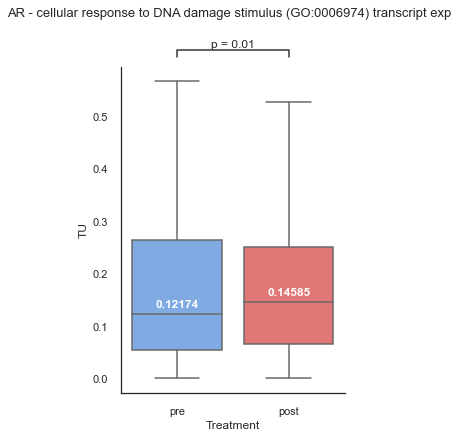

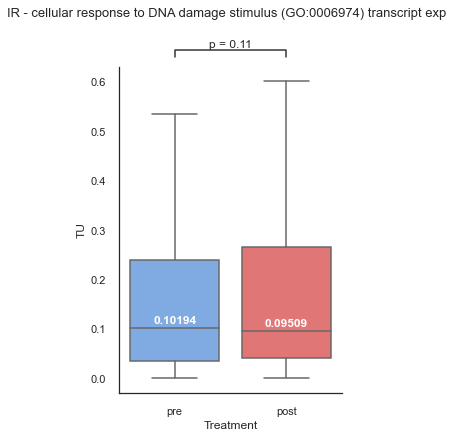

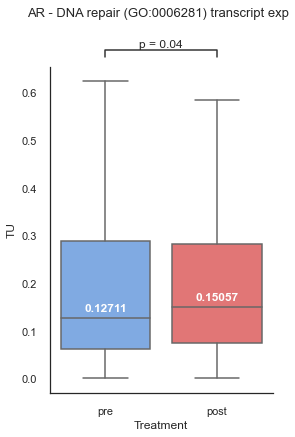

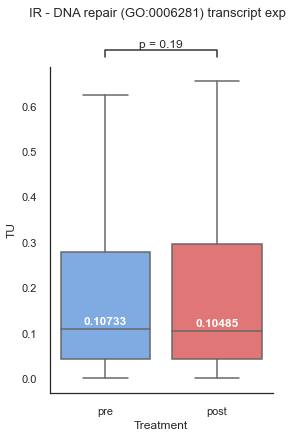

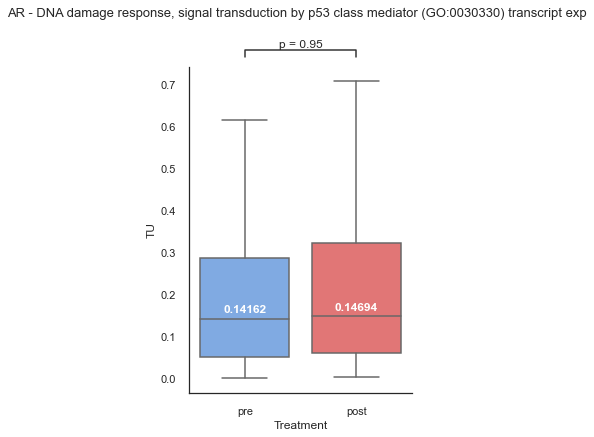

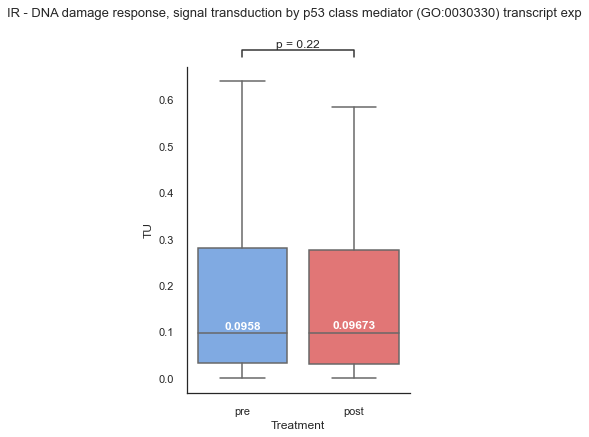

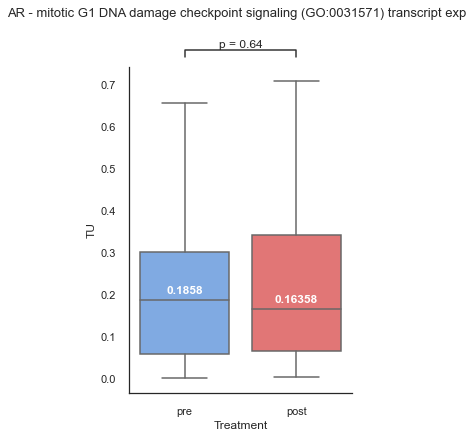

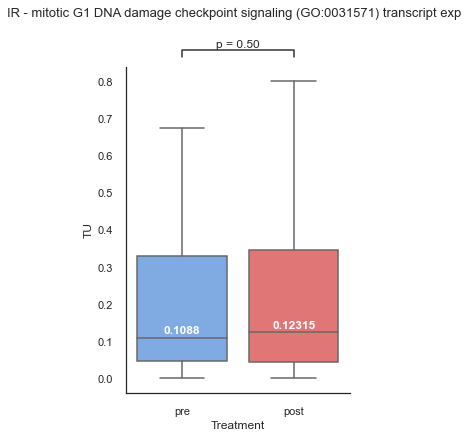

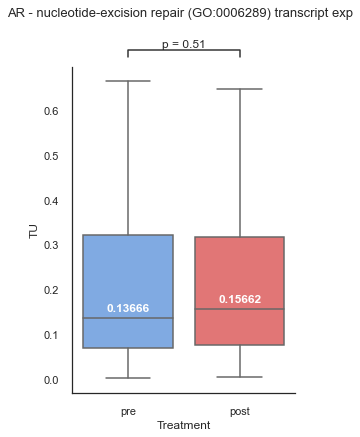

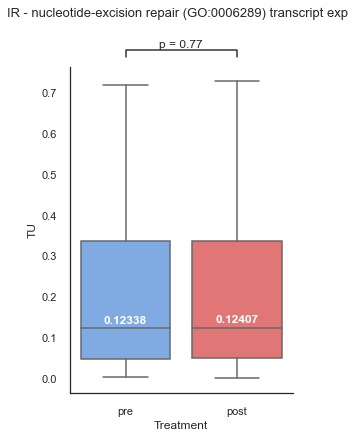

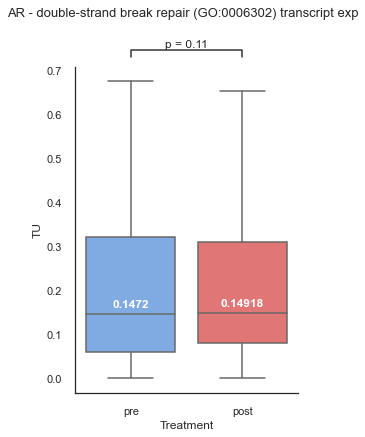

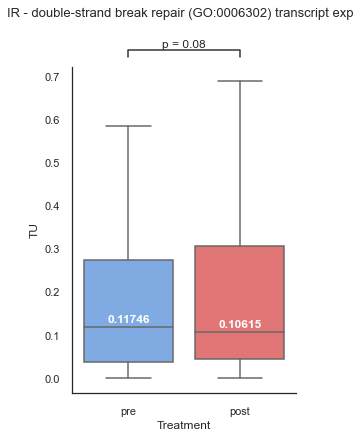

In [19]:
term_list = ['cellular response to DNA damage stimulus (GO:0006974)', 'DNA repair (GO:0006281)', 'DNA damage response, signal transduction by p53 class mediator (GO:0030330)', 'mitotic G1 DNA damage checkpoint signaling (GO:0031571)', 'nucleotide-excision repair (GO:0006289)','double-strand break repair (GO:0006302)']


DUTlist = [AR_DUTgene, IR_DUTgene]
responder = sampleinfo.loc[(sampleinfo['response']==1),'sample_full'].to_list()
nonresponder = sampleinfo.loc[(sampleinfo['response']==0),'sample_full'].to_list()
samplelist = [responder,nonresponder]
namelist = ['AR','IR']

###^^^ Major Sum #########################
for term in term_list:
    GO_genelist = go_terms[term]
    for i in range(0,2):
        enrmajorlist = majorlist[majorlist['genename'].isin(GO_genelist)]['gene_ENST']
        new_df = TU.set_index(['gene_ENST'])
        new_df = new_df[new_df.index.isin(enrmajorlist)]

        ###################responder / nonresponder##########################
        new_df = new_df[samplelist[i]]
        #####################################################################

        ## summation of majot TUs in same gene ##
        new_df['gene'] = new_df.index.str.split("-",1).str[1]
        new_df = new_df.reset_index()
        new_df = new_df.groupby('gene').sum()
        new_df = new_df.reset_index().set_index('gene')

        df_bfD = new_df[[col for col in new_df.columns if '-bfD' in col]]
        df_atD = new_df[[col for col in new_df.columns if '-atD' in col]]

        mean_bfD = list(df_bfD.mean(axis=1))
        mean_atD = list(df_atD.mean(axis=1))
        meandict = {'pre': mean_bfD, 'post': mean_atD}
        meandf = pd.DataFrame(meandict)
        meandf.index = new_df.index

        plt.figure(figsize=(4,6))
        sns.set_style("white")

        col1 = ["#70A8F2","#F36464"]

        tmplist = meandf.index.to_list()
        tmplist = tmplist*2

        ##
        figureinput = meandf.melt(var_name='Treatment', value_name='TU')
        figureinput['gene'] = tmplist
        ##


        ax = sns.boxplot(x="Treatment", y="TU", data=figureinput,  palette=col1, showfliers=False)
        #plt.ylim(0,0.16)

        from statannot import add_stat_annotation

        add_stat_annotation(ax, data=figureinput, x='Treatment', y='TU',
                    box_pairs=[("pre", "post")],
                    test='Wilcoxon', text_format='simple', loc='outside', #comparisons_correction=None,
                    )
        plt.figtext(0.5, 1.005, namelist[i] + ' - ' + term+' transcript exp', ha='center', va='center', fontsize=13)
        #plt.title(namelist2[i] + ' - ' + typelist[j]+' transcript exp', fontsize=13, y=3)
        medians = figureinput.groupby(['Treatment'])['TU'].median()
        medians = medians.iloc[::-1]
        medians = medians.round(decimals=5)
        vertical_offset = figureinput['TU'].median() * 0.1

        for xtick in ax.get_xticks():
            print(xtick)
            ax.text(xtick, medians[xtick] + vertical_offset, medians[xtick], 
                    horizontalalignment='center',size='medium',color='w',weight='semibold')
            
        sns.despine()

Using zero_method  wilcox
pre v.s. post: Wilcoxon test (paired samples) with Bonferroni correction, P_val=1.445e-02 stat=2.135e+04
0
1
Using zero_method  wilcox
pre v.s. post: Wilcoxon test (paired samples) with Bonferroni correction, P_val=1.056e-01 stat=2.285e+04
0
1
Using zero_method  wilcox
pre v.s. post: Wilcoxon test (paired samples) with Bonferroni correction, P_val=3.602e-02 stat=1.536e+04
0
1
Using zero_method  wilcox
pre v.s. post: Wilcoxon test (paired samples) with Bonferroni correction, P_val=1.915e-01 stat=1.649e+04
0
1
Using zero_method  wilcox
pre v.s. post: Wilcoxon test (paired samples) with Bonferroni correction, P_val=9.543e-01 stat=1.268e+03
0
1
Using zero_method  wilcox
pre v.s. post: Wilcoxon test (paired samples) with Bonferroni correction, P_val=2.212e-01 stat=1.096e+03
0
1
Using zero_method  wilcox
pre v.s. post: Wilcoxon test (paired samples) with Bonferroni correction, P_val=6.380e-01 stat=8.800e+02
0
1
Using zero_method  wilcox
pre v.s. post: Wilcoxon test 

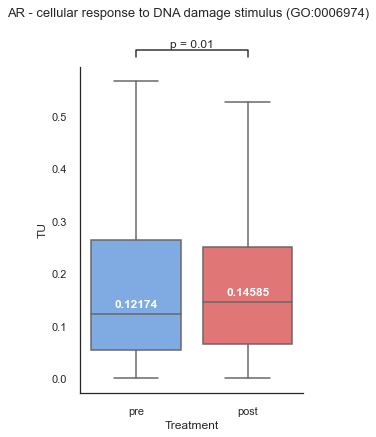

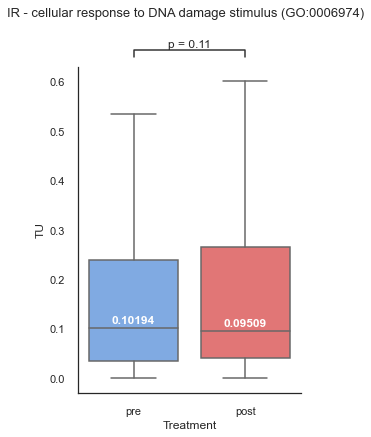

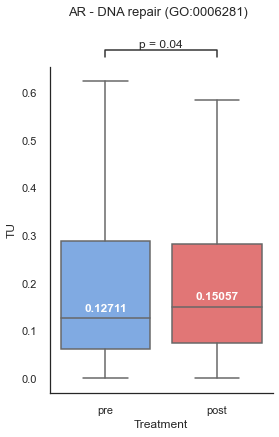

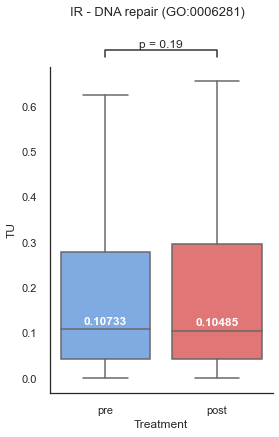

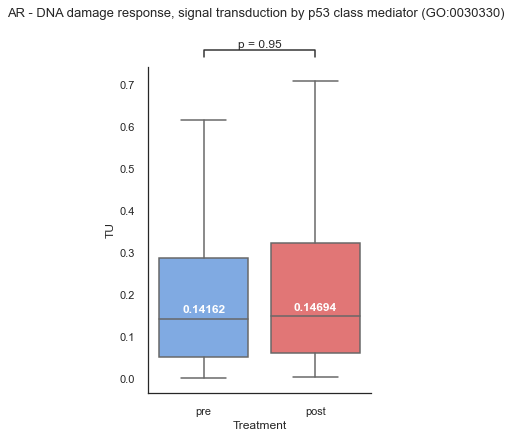

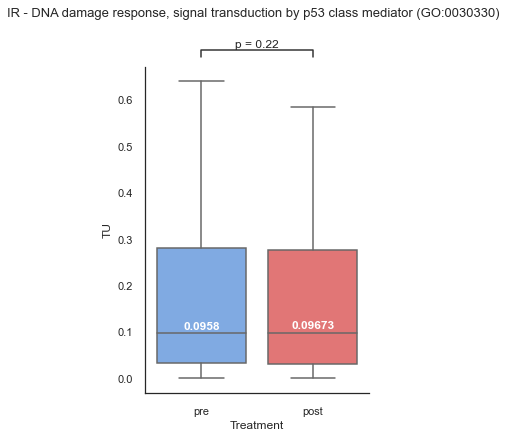

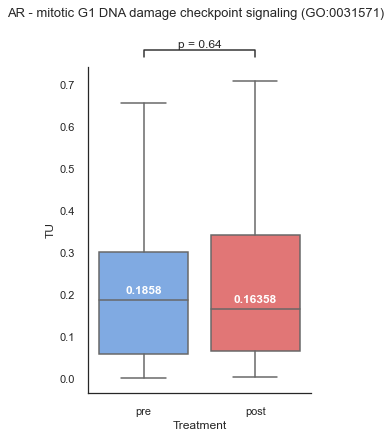

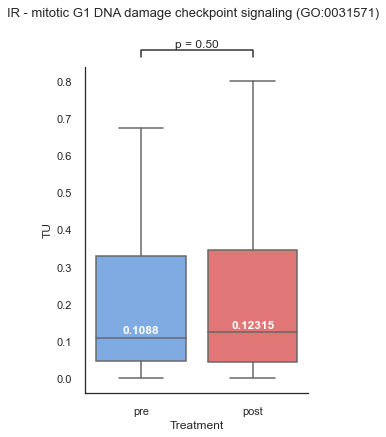

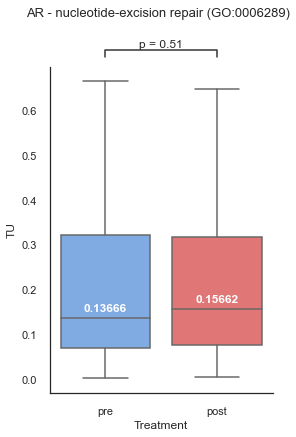

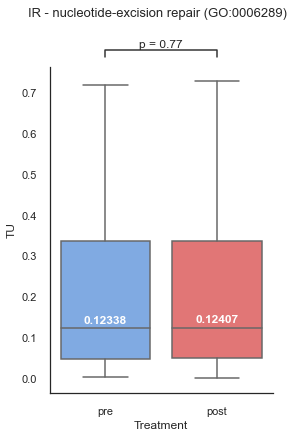

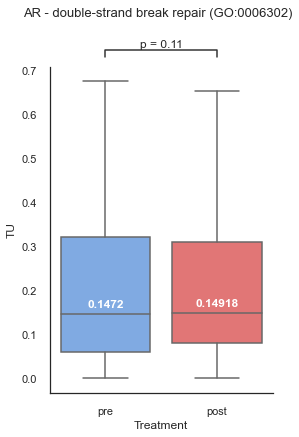

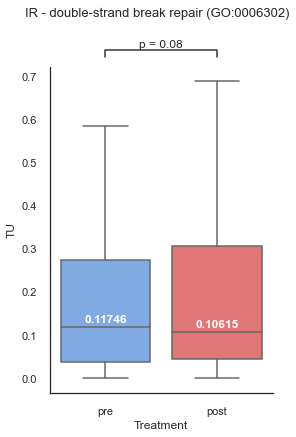

In [20]:
term_list = ['cellular response to DNA damage stimulus (GO:0006974)', 'DNA repair (GO:0006281)', 'DNA damage response, signal transduction by p53 class mediator (GO:0030330)', 'mitotic G1 DNA damage checkpoint signaling (GO:0031571)', 'nucleotide-excision repair (GO:0006289)','double-strand break repair (GO:0006302)']


DUTlist = [AR_DUTgene, IR_DUTgene]
responder = sampleinfo.loc[(sampleinfo['response']==1),'sample_full'].to_list()
nonresponder = sampleinfo.loc[(sampleinfo['response']==0),'sample_full'].to_list()
samplelist = [responder,nonresponder]
namelist = ['AR','IR']

###^^^ Major Sum #########################
for term in term_list:
    GO_genelist = go_terms[term]
    for i in range(0,2):
        enrmajorlist = majorlist[majorlist['genename'].isin(GO_genelist)]['gene_ENST']
        new_df = TU.set_index(['gene_ENST'])
        new_df = new_df[new_df.index.isin(enrmajorlist)]

        ###################responder / nonresponder##########################
        new_df = new_df[samplelist[i]]
        #####################################################################

        ## summation of majot TUs in same gene ##
        new_df['gene'] = new_df.index.str.split("-",1).str[1]
        new_df = new_df.reset_index()
        new_df = new_df.groupby('gene').sum()
        new_df = new_df.reset_index().set_index('gene')

        df_bfD = new_df[[col for col in new_df.columns if '-bfD' in col]]
        df_atD = new_df[[col for col in new_df.columns if '-atD' in col]]

        mean_bfD = list(df_bfD.mean(axis=1))
        mean_atD = list(df_atD.mean(axis=1))
        meandict = {'pre': mean_bfD, 'post': mean_atD}
        meandf = pd.DataFrame(meandict)
        meandf.index = new_df.index

        plt.figure(figsize=(4,6))
        sns.set_style("white")

        col1 = ["#70A8F2","#F36464"]

        tmplist = meandf.index.to_list()
        tmplist = tmplist*2

        ##
        figureinput = meandf.melt(var_name='Treatment', value_name='TU')
        figureinput['gene'] = tmplist
        ##


        ax = sns.boxplot(x="Treatment", y="TU", data=figureinput,  palette=col1, showfliers=False)
        #plt.ylim(0,0.16)

        from statannot import add_stat_annotation

        add_stat_annotation(ax, data=figureinput, x='Treatment', y='TU',
                    box_pairs=[("pre", "post")],
                    test='Wilcoxon', text_format='simple', loc='outside', #comparisons_correction=None,
                    )
        plt.figtext(0.5, 1.005, namelist[i] + ' - ' + term, ha='center', va='center', fontsize=13)
        #plt.title(namelist2[i] + ' - ' + typelist[j]+' transcript exp', fontsize=13, y=3)
        medians = figureinput.groupby(['Treatment'])['TU'].median()
        medians = medians.iloc[::-1]
        medians = medians.round(decimals=5)
        vertical_offset = figureinput['TU'].median() * 0.1

        for xtick in ax.get_xticks():
            print(xtick)
            ax.text(xtick, medians[xtick] + vertical_offset, medians[xtick], 
                    horizontalalignment='center',size='medium',color='w',weight='semibold')
            
        sns.despine()

Using zero_method  wilcox
pre v.s. post: Wilcoxon test (paired samples) with Bonferroni correction, P_val=1.445e-02 stat=2.135e+04
0
1
Using zero_method  wilcox
pre v.s. post: Wilcoxon test (paired samples) with Bonferroni correction, P_val=1.056e-01 stat=2.285e+04
0
1
Using zero_method  wilcox
pre v.s. post: Wilcoxon test (paired samples) with Bonferroni correction, P_val=3.602e-02 stat=1.536e+04
0
1
Using zero_method  wilcox
pre v.s. post: Wilcoxon test (paired samples) with Bonferroni correction, P_val=1.915e-01 stat=1.649e+04
0
1
Using zero_method  wilcox
pre v.s. post: Wilcoxon test (paired samples) with Bonferroni correction, P_val=9.543e-01 stat=1.268e+03
0
1
Using zero_method  wilcox
pre v.s. post: Wilcoxon test (paired samples) with Bonferroni correction, P_val=2.212e-01 stat=1.096e+03
0
1
Using zero_method  wilcox
pre v.s. post: Wilcoxon test (paired samples) with Bonferroni correction, P_val=6.380e-01 stat=8.800e+02
0
1
Using zero_method  wilcox
pre v.s. post: Wilcoxon test 

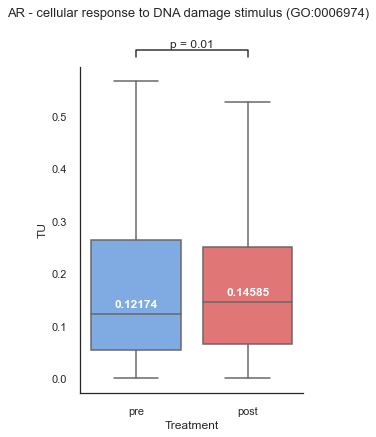

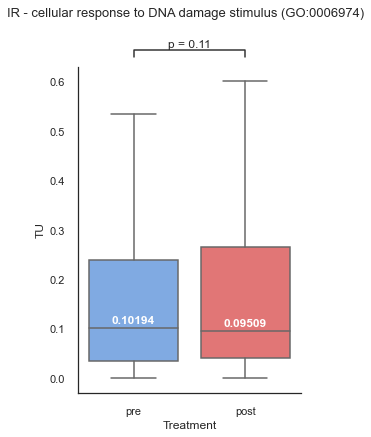

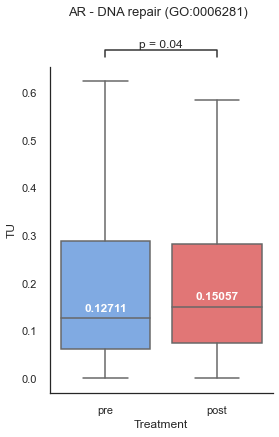

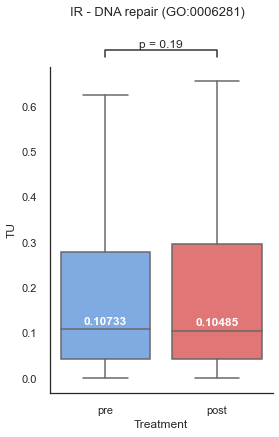

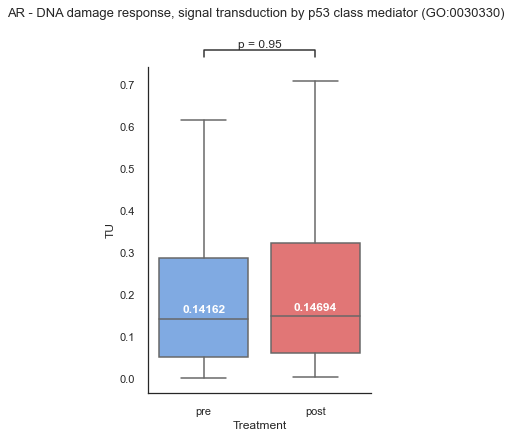

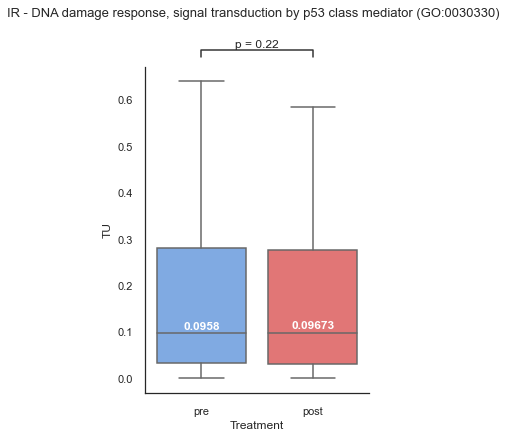

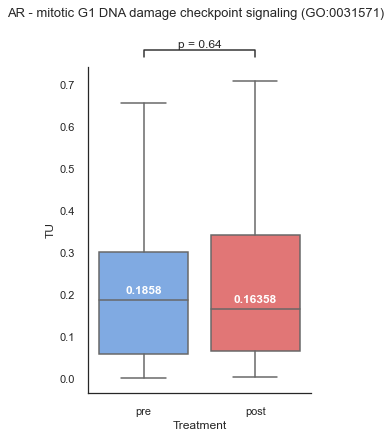

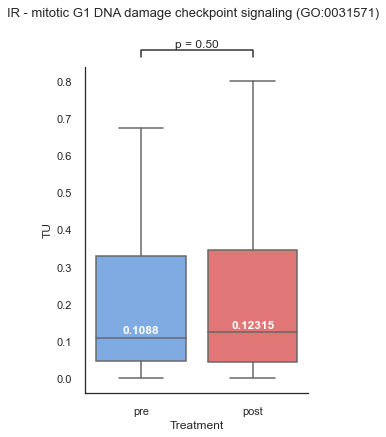

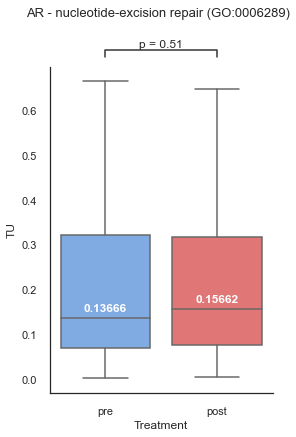

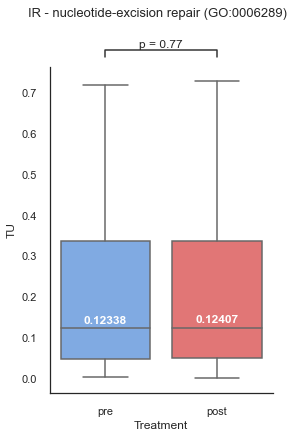

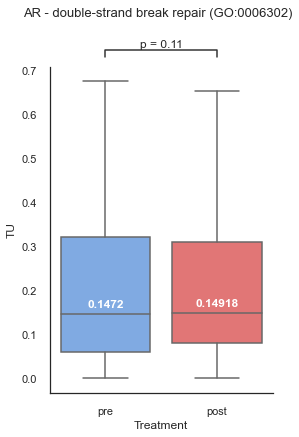

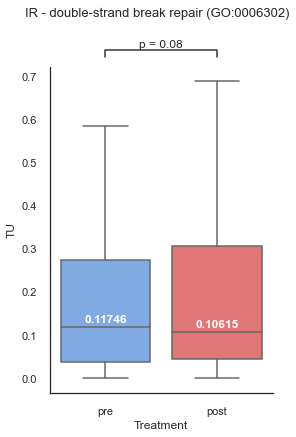

In [21]:
term_list = ['cellular response to DNA damage stimulus (GO:0006974)', 'DNA repair (GO:0006281)', 'DNA damage response, signal transduction by p53 class mediator (GO:0030330)', 'mitotic G1 DNA damage checkpoint signaling (GO:0031571)', 'nucleotide-excision repair (GO:0006289)','double-strand break repair (GO:0006302)']


DUTlist = [AR_DUTgene, IR_DUTgene]
responder = sampleinfo.loc[(sampleinfo['response']==1),'sample_full'].to_list()
nonresponder = sampleinfo.loc[(sampleinfo['response']==0),'sample_full'].to_list()
samplelist = [responder,nonresponder]
namelist = ['AR','IR']

###^^^ Major Sum #########################
for term in term_list:
    GO_genelist = go_terms[term]
    for i in range(0,2):
        enrmajorlist = majorlist[majorlist['genename'].isin(GO_genelist)]['gene_ENST']
        new_df = TU.set_index(['gene_ENST'])
        new_df = new_df[new_df.index.isin(enrmajorlist)]

        ###################responder / nonresponder##########################
        new_df = new_df[samplelist[i]]
        #####################################################################

        ## summation of majot TUs in same gene ##
        new_df['gene'] = new_df.index.str.split("-",1).str[1]
        new_df = new_df.reset_index()
        new_df = new_df.groupby('gene').sum()
        new_df = new_df.reset_index().set_index('gene')

        df_bfD = new_df[[col for col in new_df.columns if '-bfD' in col]]
        df_atD = new_df[[col for col in new_df.columns if '-atD' in col]]

        mean_bfD = list(df_bfD.mean(axis=1))
        mean_atD = list(df_atD.mean(axis=1))
        meandict = {'pre': mean_bfD, 'post': mean_atD}
        meandf = pd.DataFrame(meandict)
        meandf.index = new_df.index

        plt.figure(figsize=(4,6))
        sns.set_style("white")

        col1 = ["#70A8F2","#F36464"]

        tmplist = meandf.index.to_list()
        tmplist = tmplist*2

        ##
        figureinput = meandf.melt(var_name='Treatment', value_name='TU')
        figureinput['gene'] = tmplist
        ##


        ax = sns.boxplot(x="Treatment", y="TU", data=figureinput,  palette=col1, showfliers=False)
        #plt.ylim(0,0.16)

        from statannot import add_stat_annotation

        add_stat_annotation(ax, data=figureinput, x='Treatment', y='TU',
                    box_pairs=[("pre", "post")],
                    test='Wilcoxon', text_format='simple', loc='outside', #comparisons_correction=None,
                    )
        plt.figtext(0.5, 1.005, namelist[i] + ' - ' + term, ha='center', va='center', fontsize=13)
        #plt.title(namelist2[i] + ' - ' + typelist[j]+' transcript exp', fontsize=13, y=3)
        medians = figureinput.groupby(['Treatment'])['TU'].median()
        medians = medians.iloc[::-1]
        medians = medians.round(decimals=5)
        vertical_offset = figureinput['TU'].median() * 0.1

        for xtick in ax.get_xticks():
            print(xtick)
            ax.text(xtick, medians[xtick] + vertical_offset, medians[xtick], 
                    horizontalalignment='center',size='medium',color='w',weight='semibold')
            
        sns.despine()

In [22]:
figureinput

,Treatment,TU,gene
0,pre,0.312494,ACTR5
1,pre,0.308770,ACTR8
2,pre,0.566185,AP5S1
3,pre,0.042176,AP5Z1
4,pre,0.024065,APBB1
...,...,...,...
289,post,0.205545,XRCC5
290,post,0.406779,XRCC6
291,post,0.466439,YY1
292,post,0.061180,ZFYVE26


In [23]:
new

NameError: name 'new' is not defined

In [24]:
new)df

SyntaxError: invalid syntax (<ipython-input-24-2b006247c629>, line 1)

In [25]:
new_df

,SV-OV-P050-atD,SV-OV-P050-bfD,SV-OV-P055-atD,SV-OV-P055-bfD,SV-OV-P065-atD,SV-OV-P065-bfD,SV-OV-P067-atD,SV-OV-P067-bfD,SV-OV-P079-atD,SV-OV-P079-bfD,...,SV-OV-P164-atD,SV-OV-P164-bfD,SV-OV-P173-atD,SV-OV-P173-bfD,SV-OV-P175-atD,SV-OV-P175-bfD,SV-OV-P219-atD,SV-OV-P219-bfD,YUHS-179-atD,YUHS-179-bfD
gene,,,,,,,,,,,,,,,,,,,,,
ACTR5,0.754111,0.590229,0.000000,0.167292,0.194400,0.000000,0.796888,0.704877,0.000000,0.898759,...,0.0,0.065652,0.884475,0.215603,0.000000,0.000000,0.000000,0.000000,0.707817,0.380660
ACTR8,0.572677,0.394622,0.173623,0.247443,0.177695,0.186386,0.364092,0.515994,0.439876,0.366662,...,0.0,0.566770,0.731424,0.480083,0.516111,0.645563,0.121270,0.000000,0.086212,0.089985
AP5S1,0.975051,0.845855,0.000000,0.002079,0.356321,0.917861,0.000000,0.977060,0.717423,0.981301,...,0.0,0.276027,0.074047,0.993182,0.000000,0.000000,0.980254,0.272139,0.735111,0.448866
AP5Z1,0.008359,0.000000,0.000000,0.000000,0.000000,0.000000,0.001704,0.148786,0.000000,0.171330,...,0.0,0.000000,0.024403,0.001765,0.000000,0.000000,0.000000,0.000000,0.008253,0.004172
APBB1,0.008839,0.000000,0.000000,0.000000,0.000000,0.009644,0.000000,0.140781,0.056335,0.000024,...,0.0,0.010727,0.185586,0.076847,0.073215,0.000000,0.000000,0.008780,0.025220,0.010154
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
XRCC5,0.239858,0.478836,0.051633,0.556587,0.000182,0.262874,0.323316,0.334007,0.169244,0.633644,...,0.0,0.208760,0.232120,0.114826,0.606247,0.000000,0.481755,0.000000,0.000000,0.000000
XRCC6,0.350533,0.067692,0.534254,0.027961,0.038554,0.159401,0.307024,0.176213,0.196730,0.071075,...,0.0,0.446560,0.346784,0.417576,0.845769,0.421561,0.324155,0.000000,0.944812,0.540620
YY1,0.780152,0.062088,0.741723,0.639610,0.086853,0.857523,0.856451,0.080507,0.655847,0.751368,...,0.0,0.227751,0.877498,0.872158,0.527321,0.014655,0.710504,0.000000,0.000000,0.000000
